In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("D:\yt series\processed_dataset.csv")
df.head()

,PatientID,Age,Gender,BMI,BloodPressure,GlucoseLevel,Insulin,SkinThickness,DiabetesPedigreeFunction,PhysicalActivity,Smoking,Alcohol_Intake,FamilyHistory,Outcome
0,1,45,1,28.5,85,150,130.000000,32,0.62,0,1,1,1,1
1,2,34,0,22.3,70,98,80.000000,20,0.25,2,0,0,0,0
2,3,50,1,31.2,90,170,121.693878,35,0.78,0,1,2,1,1
3,4,29,0,24.1,75,110,90.000000,25,0.30,1,0,0,0,0
4,6,41,0,27.8,80,140,120.000000,30,0.55,1,0,1,1,1


In [10]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [35]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

In [14]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [15]:
svm = SVC(probability=True)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)

In [16]:
def evaluate_model(y_test, y_pred, model_name):
    print(f"\n🔹 {model_name} Performance:")
    
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [31]:
evaluate_model(y_test, y_pred_lr, "Logistic Regression")


🔹 Logistic Regression Performance:
Accuracy: 0.95
Precision: 1.0
Recall: 0.8571428571428571
F1 Score: 0.9230769230769231

Confusion Matrix:
[[13  0]
 [ 1  6]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        13
           1       1.00      0.86      0.92         7

    accuracy                           0.95        20
   macro avg       0.96      0.93      0.94        20
weighted avg       0.95      0.95      0.95        20



In [32]:
evaluate_model(y_test, y_pred_knn, "KNN")


🔹 KNN Performance:
Accuracy: 0.95
Precision: 1.0
Recall: 0.8571428571428571
F1 Score: 0.9230769230769231

Confusion Matrix:
[[13  0]
 [ 1  6]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        13
           1       1.00      0.86      0.92         7

    accuracy                           0.95        20
   macro avg       0.96      0.93      0.94        20
weighted avg       0.95      0.95      0.95        20



In [33]:
evaluate_model(y_test, y_pred_svm, "SVM")


🔹 SVM Performance:
Accuracy: 0.95
Precision: 1.0
Recall: 0.8571428571428571
F1 Score: 0.9230769230769231

Confusion Matrix:
[[13  0]
 [ 1  6]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        13
           1       1.00      0.86      0.92         7

    accuracy                           0.95        20
   macro avg       0.96      0.93      0.94        20
weighted avg       0.95      0.95      0.95        20



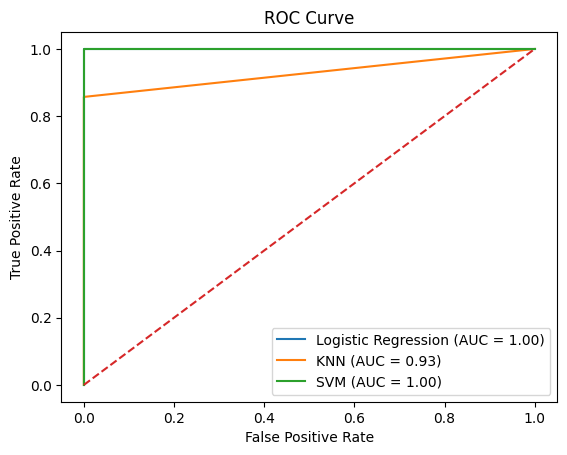

In [18]:
def plot_roc(model, X_test, y_test, name):
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

plt.figure()

plot_roc(lr, X_test, y_test, "Logistic Regression")
plot_roc(knn, X_test, y_test, "KNN")
plot_roc(svm, X_test, y_test, "SVM")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

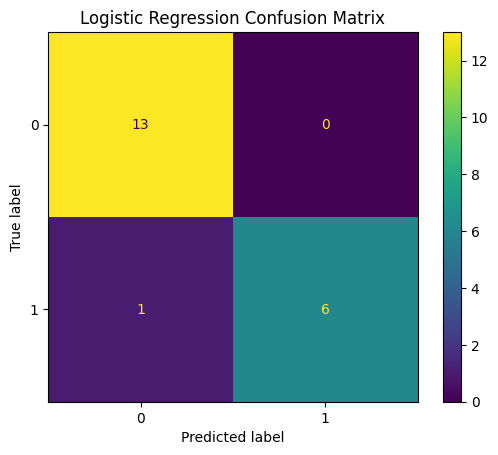

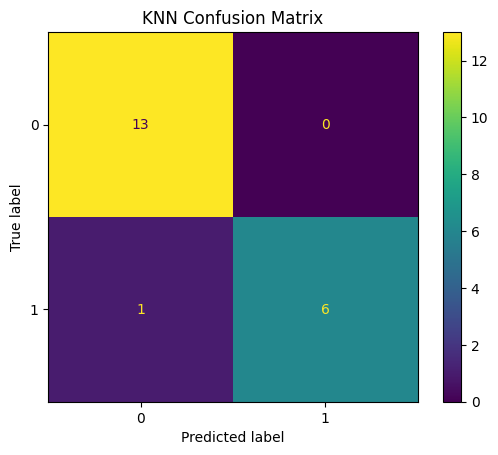

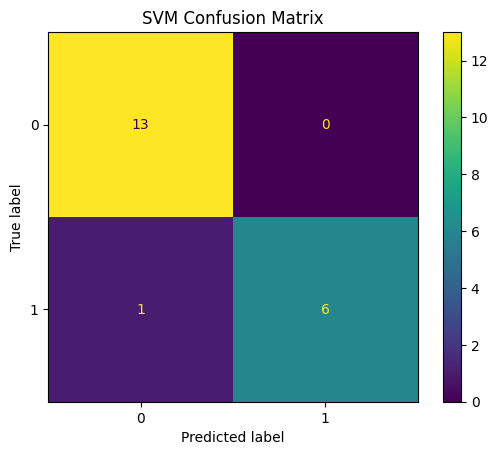

In [30]:
plot_confusion(lr, X_test, y_test, "Logistic Regression")
plot_confusion(knn, X_test, y_test, "KNN")
plot_confusion(svm, X_test, y_test, "SVM")

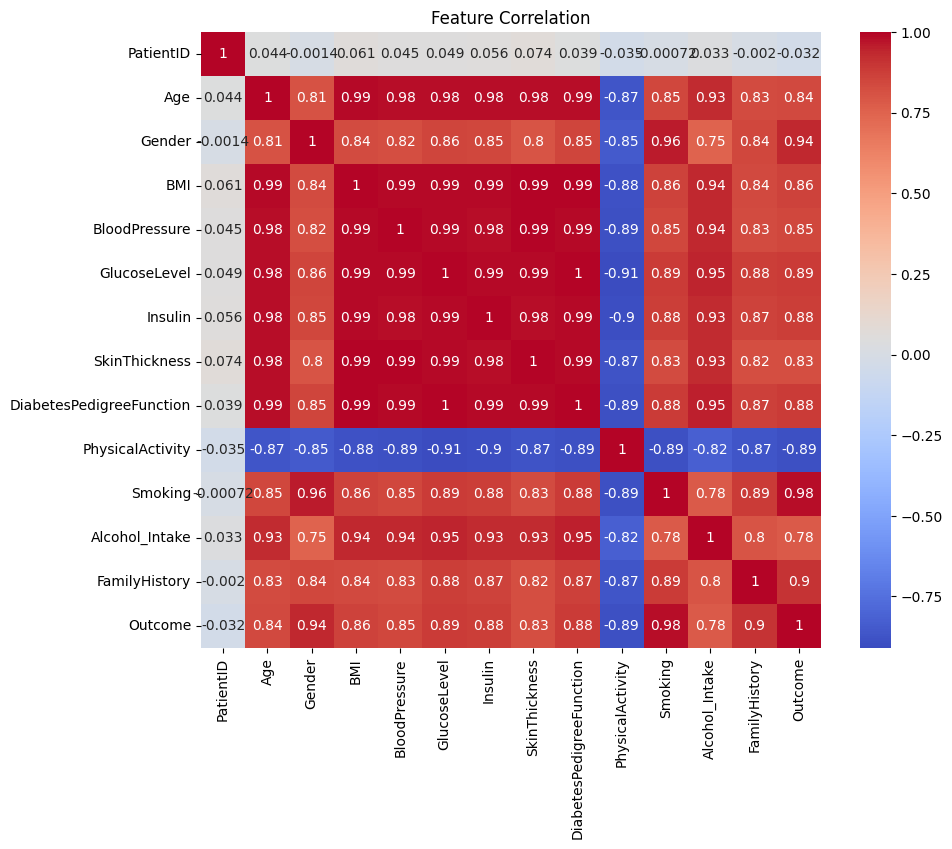

In [19]:
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

Testing is done, predicted for diabetic and non diabetic cases, model achieved overall accuracy of 95.0%, confusion matrix and classification reports are also included.